# Chapter 33 Lab — Dynamic Connectivity (Python)

In this lab you will stress-test the workhorse of dynamic functional connectivity (DFC) analysis — the sliding-window correlation — and meet a model-based alternative. We follow a four-step arc:

1. **Fool yourself first**: compute sliding-window correlations on data whose true correlation *never changes*, and watch convincing-looking "dynamics" appear out of pure sampling variability
2. **The window-length dilemma**: see how window length trades estimation noise (short windows) against blurred dynamics (long windows)
3. **Track a real regime switch**: compare sliding windows with an exponentially weighted, DCC-flavored estimator on a signal whose correlation truly changes
4. **Test against a stationary null**: use phase-randomized surrogates to ask whether observed correlation variability exceeds what a purely static process would produce

Because we simulate the data with known ground truth, you always know whether the "dynamics" you see are real — the check you never get with real data.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `pandas`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part6/ch33-dynamic-connectivity).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(33)


def sliding_corr(dat, w):
    """Sliding-window correlation between the two columns of `dat`.

    The window ENDS at time t (it uses samples t-w+1 ... t), mirroring
    sliding_window.m in Lindquist's Dynamic Correlation Toolbox
    (github.com/canlab/Lindquist_Dynamic_Correlation). Implemented with
    rolling sums so it is fast enough for surrogate-testing loops.
    """
    T = dat.shape[0]
    x, y = dat[:, 0], dat[:, 1]

    def rollsum(v):                       # sum over each length-w window
        c = np.concatenate(([0.0], np.cumsum(v)))
        return c[w:] - c[:-w]

    sx, sy = rollsum(x), rollsum(y)
    cov = rollsum(x * y) - sx * sy / w
    varprod = (rollsum(x * x) - sx**2 / w) * (rollsum(y * y) - sy**2 / w)

    rho = np.full(T, np.nan)
    rho[w - 1:] = cov / np.sqrt(varprod)
    return rho

## 1. Spurious dynamics from a purely static process

The first thing to know about sliding-window correlations is how *lively* they look when nothing is happening. We simulate two time series (600 "TRs") whose true correlation is a **constant** $r = 0.4$ — a *static-correlation null*. By construction there are no connectivity dynamics of any kind, so every wiggle in the windowed correlation below is sampling noise.

Windowed correlation ranges from 0.03 to 0.78 — with no true dynamics at all


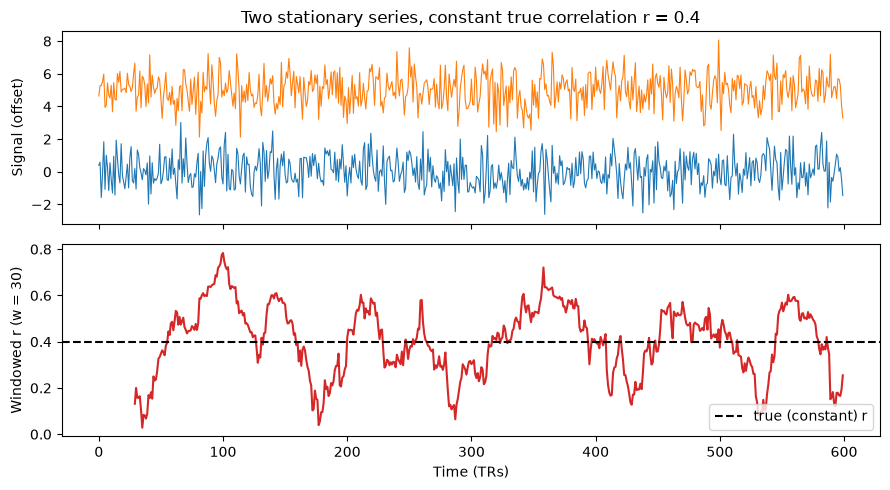

In [2]:
T, r_true, w = 600, 0.4, 30    # T = time points (TRs), r_true = true correlation, w = window length

C = np.array([[1.0, r_true], [r_true, 1.0]])   # 2x2 correlation matrix of the generating process
dat_static = rng.standard_normal((T, 2)) @ np.linalg.cholesky(C).T

rho_sw = sliding_corr(dat_static, w)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(dat_static[:, 0], lw=0.8)
axes[0].plot(dat_static[:, 1] + 5, lw=0.8)
axes[0].set_ylabel("Signal (offset)")
axes[0].set_title(f"Two stationary series, constant true correlation r = {r_true}")
axes[1].plot(rho_sw, color="tab:red")
axes[1].axhline(r_true, color="k", ls="--", label="true (constant) r")
axes[1].set_xlabel("Time (TRs)")
axes[1].set_ylabel(f"Windowed r (w = {w})")
axes[1].legend(loc="lower right")
plt.tight_layout()

print(f"Windowed correlation ranges from {np.nanmin(rho_sw):.2f} to "
      f"{np.nanmax(rho_sw):.2f} — with no true dynamics at all")

**What happened?** A correlation estimated from only $w = 30$ samples has a large standard error — in Fisher-$z$ units roughly $1/\sqrt{w-3} \approx 0.19$ — so the windowed estimate sweeps across a wide range even though the generating process never changes. If you fed matrices like these to a clustering algorithm, you would happily recover "brain states" from pure noise.

This is the heart of the critique by Laumann and colleagues: much of the apparent connectivity dynamics at rest is consistent with sampling variability (plus motion and drowsiness). And real fMRI is *worse* than this idealized simulation — noise autocorrelation and nuisance regression (motion, drift, physiology) both reduce the effective degrees of freedom in every window, inflating the swings further.

## 2. The window-length dilemma

Longer windows average more samples, so the spurious fluctuations shrink — roughly like $1/\sqrt{w}$. So why not always use very long windows? Because windowing is equivalent to low-pass filtering the true connectivity time course with cutoff $\approx 1/w$: whatever is slower than the window survives, and whatever is faster is smeared away (Section 3 shows this on real dynamics). This is why a common rule of thumb sets the window length to the reciprocal of the lowest frequency present in the preprocessed signal — and why the choice of $w$ is a genuine **bias–variance tradeoff**, not a nuisance detail.

,SD of windowed r (static data)
w = 15,0.230
w = 30,0.151
w = 60,0.097
w = 120,0.053


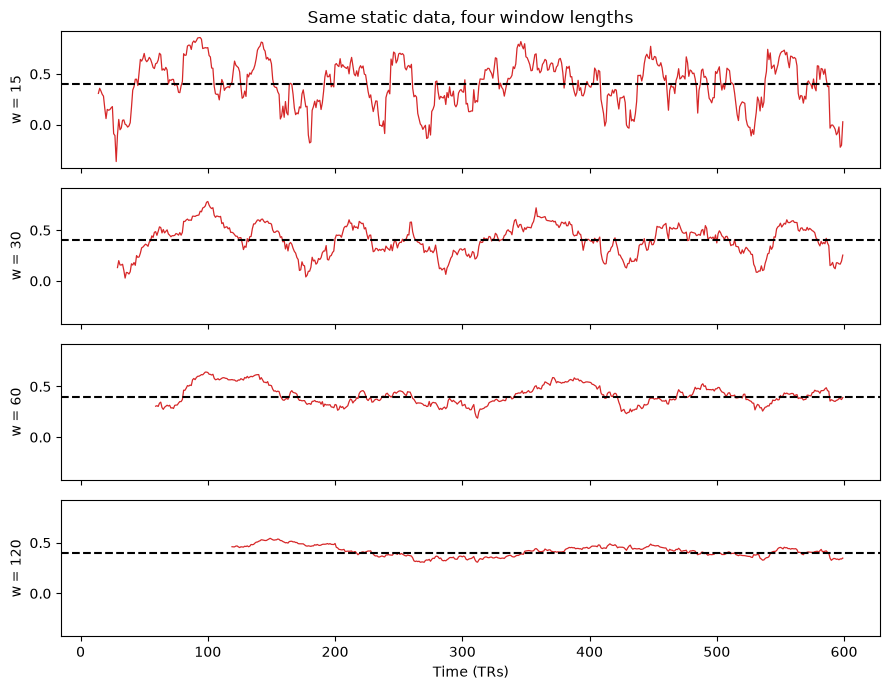

In [3]:
windows = [15, 30, 60, 120]    # window lengths to compare (TRs)

fig, axes = plt.subplots(len(windows), 1, figsize=(9, 7), sharex=True, sharey=True)
sds = {}
for ax, wi in zip(axes, windows):
    r = sliding_corr(dat_static, wi)
    sds[f"w = {wi}"] = np.nanstd(r)
    ax.plot(r, color="tab:red", lw=0.9)
    ax.axhline(r_true, color="k", ls="--")
    ax.set_ylabel(f"w = {wi}")
axes[0].set_title("Same static data, four window lengths")
axes[-1].set_xlabel("Time (TRs)")
plt.tight_layout()

pd.DataFrame({"SD of windowed r (static data)": sds}).round(3)

The standard deviation of the (entirely spurious) fluctuations roughly halves each time the window length quadruples. Long windows are the cure for noise — but, as we now show, they are also the disease for detecting real change.

## 3. Tracking a true regime switch: sliding window vs. a DCC-flavored estimator

Now we give the data genuine ground-truth dynamics: the correlation alternates between $+0.7$ and $-0.3$ every 150 TRs — four "brain states" in sequence.

We compare the sliding window with an **exponentially weighted moving average (EWMA)** correlation, a fixed-parameter cousin of Dynamic Conditional Correlation (DCC). Instead of giving equal weight to the last $w$ samples and zero weight to everything older, the EWMA updates a running covariance recursively:

::::{div}
:class: eq-tip
$$
q_{ij}(t) = (1-\lambda)\, z_i(t)\, z_j(t) + \lambda\, q_{ij}(t-1),
\qquad
\hat\rho_{ij}(t) = \frac{q_{ij}(t)}{\sqrt{q_{ii}(t)\, q_{jj}(t)}} .
$$
:::{div}
:class: eq-tip-text
qᵢⱼ(t) — running (unnormalized) covariance between series i and j · zᵢ(t) — standardized signal value of series i at time t · λ — forgetting factor, 0 < λ < 1 · ρ̂ᵢⱼ(t) — time-varying correlation estimate
:::
::::
:::{div}
:class: eq-where
*where* $q_{ij}(t)$ *is a running (unnormalized) covariance between series* $i$ *and* $j$*,* $z_i(t)$ *and* $z_j(t)$ *are the standardized signal values at time* $t$*,* $\lambda \in (0,1)$ *is the forgetting factor, and* $\hat\rho_{ij}(t)$ *is the resulting time-varying correlation estimate.*
:::

Recent samples get weight $(1-\lambda)$ and older evidence decays geometrically — $\lambda$ is a *forgetting factor*, playing the same role as the gain in a Kalman filter (a learning rate that trades responsiveness against noise). Full DCC (Lindquist et al., 2014) goes two steps further: a GARCH model first removes time-varying *variance* from each series, and the smoothing parameters are then estimated from the data by maximum likelihood — so no window length (or $\lambda$) is chosen a priori. See `DCC.m` in [Lindquist's Dynamic Correlation Toolbox](https://github.com/canlab/Lindquist_Dynamic_Correlation) (also distributed with CanlabCore).

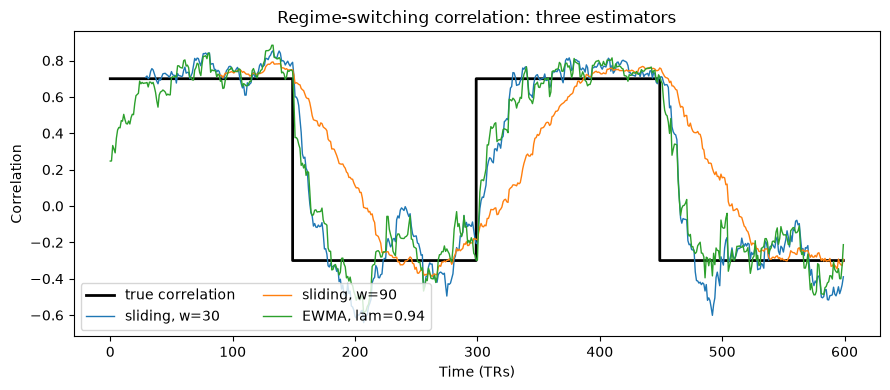

In [4]:
# True correlation switches every 150 TRs: +0.7, -0.3, +0.7, -0.3
r_t = np.where((np.arange(T) // 150) % 2 == 0, 0.7, -0.3)   # ground-truth correlation path

z = rng.standard_normal((T, 2))
dat_dyn = np.column_stack([z[:, 0],
                           r_t * z[:, 0] + np.sqrt(1 - r_t**2) * z[:, 1]])


def ewma_corr(dat, lam=0.94):   # lam = forgetting factor (weight on past evidence)
    """Exponentially weighted moving correlation (DCC-flavored, fixed lambda).

    Full DCC also fits GARCH variances and estimates the smoothing
    parameters from the data by maximum likelihood.
    """
    Tn = dat.shape[0]
    Q = np.cov(dat.T)                 # initialize from the static covariance
    rho = np.zeros(Tn)
    for t in range(Tn):
        zt = dat[t]
        Q = lam * Q + (1 - lam) * np.outer(zt, zt)
        rho[t] = Q[0, 1] / np.sqrt(Q[0, 0] * Q[1, 1])
    return rho


estimates = {
    "sliding, w=30": sliding_corr(dat_dyn, 30),
    "sliding, w=90": sliding_corr(dat_dyn, 90),
    "EWMA, lam=0.94": ewma_corr(dat_dyn),
}

plt.figure(figsize=(9, 4))
plt.step(np.arange(T), r_t, color="k", lw=2, label="true correlation")
for name, est in estimates.items():
    plt.plot(est, lw=1, label=name)
plt.xlabel("Time (TRs)"); plt.ylabel("Correlation")
plt.legend(loc="lower left", ncol=2)
plt.title("Regime-switching correlation: three estimators")
plt.tight_layout()

In [5]:
valid = slice(120, None)      # skip burn-in where the long window is undefined
rmse = {name: np.sqrt(np.nanmean((est[valid] - r_t[valid]) ** 2))
        for name, est in estimates.items()}
pd.DataFrame({"RMSE vs true correlation": rmse}).round(3)

,RMSE vs true correlation
"sliding, w=30",0.256
"sliding, w=90",0.416
"EWMA, lam=0.94",0.226


**Reading the race.** The short window ($w=30$) follows the transitions but is noisy within each regime. The long window ($w=90$) is smooth but smears every transition across ~90 TRs — the low-pass bias in action: for a while it reports a correlation near zero that the brain never actually produced. The EWMA discounts old samples *smoothly* rather than abruptly, and typically achieves a better noise/adaptation compromise (lower RMSE) than either window.

The deeper point is not that EWMA wins — with a fixed $\lambda$ it faces the same bias–variance dial, just with a smoother weighting profile. The point is that model-based estimators like DCC turn the dial *using the data*, estimating how quickly correlations evolve instead of asking you to guess a window length. They also inherit robustness from the GARCH step: time-varying noise variance, which sliding windows happily convert into fake correlation dynamics, is removed before the correlation is estimated.

## 4. Is it really dynamic? Testing against a stationary null

Finally, the discipline that should accompany every DFC analysis: an explicit **stationary null model**.

- **Test statistic:** the standard deviation of the windowed correlation across time — big if connectivity really fluctuates, small if it is static.
- **Null hypothesis:** the data come from a *stationary* process with the observed static correlation and autocorrelation.
- **Surrogates:** *phase randomization*. Fourier-transform each series, rotate the coefficient at every frequency by a random phase — using the **same** rotation for both series at each frequency — and invert. This preserves each series' power spectrum (hence its autocorrelation) and their cross-spectrum (hence the static correlation), but the surrogate is stationary by construction: any true correlation dynamics are destroyed.

If the observed statistic sits comfortably inside the surrogate distribution, the "dynamics" need no explanation beyond sampling variability.

In [6]:
def phase_randomize(dat, rng):
    """Stationary surrogate preserving each power spectrum and the cross-spectrum."""
    Tn = dat.shape[0]
    F = np.fft.rfft(dat, axis=0)
    phi = rng.uniform(0, 2 * np.pi, size=(F.shape[0], 1))  # same rotation, both columns
    phi[0] = 0.0                                           # keep the mean real
    if Tn % 2 == 0:
        phi[-1] = 0.0                                      # keep the Nyquist bin real
    return np.fft.irfft(F * np.exp(1j * phi), n=Tn, axis=0)


def stationarity_test(dat, w, n_sur=500):   # n_sur = number of surrogates; more -> stabler tail p-values
    obs = np.nanstd(sliding_corr(dat, w))
    null = np.array([np.nanstd(sliding_corr(phase_randomize(dat, rng), w))
                     for _ in range(n_sur)])
    p = (1 + np.sum(null >= obs)) / (n_sur + 1)
    return obs, null, p


obs_s, null_s, p_s = stationarity_test(dat_static, w)
obs_d, null_d, p_d = stationarity_test(dat_dyn, w)

print(f"Static-null data:      SD of windowed r = {obs_s:.3f}, p = {p_s:.3f}")
print(f"Regime-switching data: SD of windowed r = {obs_d:.3f}, p = {p_d:.3f}")

Static-null data:      SD of windowed r = 0.151, p = 0.499
Regime-switching data: SD of windowed r = 0.513, p = 0.002


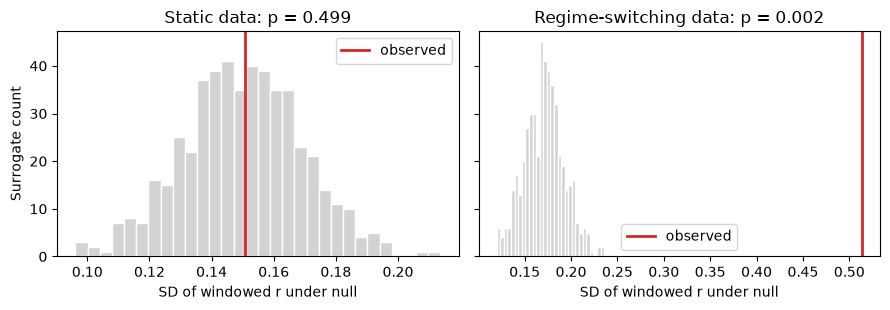

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (null, obs, ttl, p) in zip(axes, [
        (null_s, obs_s, "Static data", p_s),
        (null_d, obs_d, "Regime-switching data", p_d)]):
    ax.hist(null, bins=30, color="lightgray", edgecolor="white")
    ax.axvline(obs, color="tab:red", lw=2, label="observed")
    ax.set_title(f"{ttl}: p = {p:.3f}")
    ax.set_xlabel("SD of windowed r under null")
    ax.legend()
axes[0].set_ylabel("Surrogate count")
plt.tight_layout()

The test behaves exactly as it should: for the static data the observed variability is entirely typical of a stationary process (no evidence of dynamics), while for the regime-switching data the observed statistic sits far outside the null distribution and the test rejects decisively.

## Wrapping up

- **Sliding-window correlations fluctuate vigorously on static data.** Never interpret raw windowed variability — or states clustered from it — as evidence of dynamics.
- **Window length is a bias–variance dial and a low-pass filter.** Short windows are noisy; long windows blur real transitions and can report correlations the brain never produced.
- **Model-based estimators (EWMA, and DCC with its GARCH step) replace the arbitrary window with data-driven weights** and are less fooled by time-varying noise variance.
- **Always test against a stationary null** (e.g., phase-randomized surrogates), and in real data also rule out motion, arousal changes, and time-varying mean shifts before interpreting brain states as neuronal.

From here, the chapter's second half — clustering time-resolved matrices into states (k-means and its assumptions) and estimating states directly with hidden Markov or change-point models — picks up where these estimators leave off. For a production-grade DCC implementation, see [Lindquist's Dynamic Correlation Toolbox](https://github.com/canlab/Lindquist_Dynamic_Correlation).